# Validación Externa Supervisada — SWaT A12 (Marzo 2026)

**Diferencias clave respecto al notebook A6/A7:**

| Aspecto | A6/A7 (anterior) | A12 (este notebook) |
|---------|-----------------|---------------------|
| Datos de ataque | CSV diferente (A6 Dic 2019) | **Mismo CSV A12** (attack_label ya incluido) |
| Asignación de etiquetas | Manual desde log de sesión | **Directa desde columna attack_label** |
| Domain shift | Sí (A7→A6) — requería diagnóstico | **No** — mismo dataset, misma distribución |
| Re-calibración | Datos pre-primer ataque | **Datos normales (label=0) del mismo CSV** |
| Arquitectura | 2 MaxPool (window=60) | **1 MaxPool (window=30)** |
| Análisis ataques | Por ciclo temporal | **Por attack_id y attack_name** |

**Ventaja principal:** al usar el mismo CSV, los modelos ya conocen la distribución
de normalidad del sistema. Sin domain shift → los umbrales internos son directamente
aplicables y las métricas de detección son las más informativas posibles.


## 0. Imports

In [1]:
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import json
import joblib
import warnings
from pathlib import Path
from torch.utils.data import DataLoader, TensorDataset
from sklearn.metrics import (
    roc_auc_score, average_precision_score,
    roc_curve, precision_recall_curve,
)
warnings.filterwarnings('ignore')
pd.set_option('display.float_format', '{:.4f}'.format)


In [2]:
SEED = 42
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print('Device:', device)


Device: cuda


## 1. Rutas del proyecto

In [3]:
current_dir  = Path.cwd()
PROJECT_ROOT = current_dir if (current_dir / 'data').exists() else current_dir.parent

# Mismo CSV de A12 — ahora usamos las filas de ataque (label=1)
RAW_CSV = PROJECT_ROOT / 'data' / 'clean' / 'SWaT.A12_OTDataset_Mar_26' / '11-Mar-2026_0900_1700_labeled.csv'

# Artefactos del pipeline interno A12
INTERNAL_ARTIFACTS_DIR = PROJECT_ROOT / 'artifacts' / 'tstr_internal_validation_a12'
MODELS_DIR             = PROJECT_ROOT / 'models'    / 'detectors' / 'conv1d_tstr_internal_a12'
EXTERNAL_RESULTS_DIR   = PROJECT_ROOT / 'artifacts' / 'tstr_external_validation_a12'
EXTERNAL_RESULTS_DIR.mkdir(parents=True, exist_ok=True)

print('PROJECT_ROOT:', PROJECT_ROOT.resolve())
required = [
    RAW_CSV,
    INTERNAL_ARTIFACTS_DIR / 'scaler_cont.pkl',
    INTERNAL_ARTIFACTS_DIR / 'disc_max.pkl',
    INTERNAL_ARTIFACTS_DIR / 'columns_config.json',
    INTERNAL_ARTIFACTS_DIR / 'config.json',
    MODELS_DIR / 'real_only',
    MODELS_DIR / 'synthetic_only',
    MODELS_DIR / 'real_plus_synthetic',
]
all_ok = True
for p in required:
    e = p.exists()
    print(f"  {'OK' if e else 'X'} {p.name}")
    if not e: all_ok = False
if all_ok: print('Todos los artefactos encontrados.')
else: raise FileNotFoundError('Faltan artefactos.')


PROJECT_ROOT: D:\Documentos\Uniandes\12 Semestre\PROYECTO DE GRADO\repoPrincipal\ics-synthetic-data-augmentation
  OK 11-Mar-2026_0900_1700_labeled.csv
  OK scaler_cont.pkl
  OK disc_max.pkl
  OK columns_config.json
  OK config.json
  OK real_only
  OK synthetic_only
  OK real_plus_synthetic
Todos los artefactos encontrados.


## 2. Cargar artefactos del pipeline interno A12

In [4]:
with open(INTERNAL_ARTIFACTS_DIR / 'columns_config.json') as f:
    col_cfg = json.load(f)
with open(INTERNAL_ARTIFACTS_DIR / 'config.json') as f:
    internal_config = json.load(f)

continuous_cols = col_cfg['continuous_cols']
discrete_cols   = col_cfg['discrete_cols']
feature_cols    = col_cfg['feature_cols']
WINDOW_SIZE     = int(internal_config['window_size'])   # 30
STRIDE          = int(internal_config['stride'])        # 5
SCENARIOS       = internal_config['scenarios']

scaler_cont  = joblib.load(INTERNAL_ARTIFACTS_DIR / 'scaler_cont.pkl')
disc_max_raw = joblib.load(INTERNAL_ARTIFACTS_DIR / 'disc_max.pkl')
disc_max     = disc_max_raw if isinstance(disc_max_raw, pd.Series) \
               else pd.Series(disc_max_raw).reindex(discrete_cols).replace(0, 1)

# Cargar tau_dicts de cada escenario
tau_dicts = {}
for scenario in SCENARIOS:
    tau_path = MODELS_DIR / scenario / 'tau_dict.json'
    with open(tau_path) as f:
        tau_dicts[scenario] = json.load(f)

print(f'Scenarios: {SCENARIOS}')
print(f'Window: {WINDOW_SIZE} | Stride: {STRIDE}')
print(f'Continuas: {len(continuous_cols)} | Discretas: {len(discrete_cols)}')
print('\nUmbrales internos (τ) del entrenamiento A12:')
for sc, taus in tau_dicts.items():
    print(f'  {sc:<25} p90={float(taus["p90"]):.4f}  p95={float(taus["p95"]):.4f}  p99={float(taus["p99"]):.4f}')


Scenarios: ['real_only', 'synthetic_only', 'real_plus_synthetic']
Window: 30 | Stride: 5
Continuas: 31 | Discretas: 31

Umbrales internos (τ) del entrenamiento A12:
  real_only                 p90=0.1121  p95=1.5668  p99=1.6880
  synthetic_only            p90=0.3081  p95=26.2912  p99=27.0734
  real_plus_synthetic       p90=0.1519  p95=1.4574  p99=1.7033


## 3. Cargar CSV A12 completo

A diferencia de A6, las etiquetas de ataque ya están en la columna `attack_label`.
No es necesaria ninguna reconstrucción manual desde el log de sesión.


In [5]:
META_COLS = ['attack_label','attack_id','attack_name','attack_targets',
             'attack_start_time','attack_end_time']

df_raw = pd.read_csv(RAW_CSV, low_memory=False)
df_raw['t_stamp']      = pd.to_datetime(df_raw['t_stamp'], errors='coerce')
df_raw['attack_label'] = pd.to_numeric(df_raw['attack_label'], errors='coerce').fillna(0).astype(int)
df_raw = df_raw.sort_values('t_stamp').reset_index(drop=True)

n_normal = (df_raw['attack_label']==0).sum()
n_attack = (df_raw['attack_label']==1).sum()
print(f'Total filas: {len(df_raw)}')
print(f'Normal (0): {n_normal} ({100*n_normal/len(df_raw):.1f}%)')
print(f'Ataque (1): {n_attack} ({100*n_attack/len(df_raw):.1f}%)')
print(f'Periodo: {df_raw["t_stamp"].min()} -> {df_raw["t_stamp"].max()}')

# Resumen de ataques únicos
attack_df = df_raw[df_raw['attack_label']==1][['attack_id','attack_name','attack_targets']].drop_duplicates('attack_id')
print(f'\nNúmero de ataques únicos: {len(attack_df)}')
display(attack_df.reset_index(drop=True))


Total filas: 28860
Normal (0): 25740 (89.2%)
Ataque (1): 3120 (10.8%)
Periodo: 2026-03-11 09:00:00 -> 2026-03-11 17:00:59

Número de ataques únicos: 11


,attack_id,attack_name,attack_targets
0,1.0000,"Stage 5 Valve Manipulation — MV503/504 Open, M...",MV501–504
1,2.0000,"Stage 1 Flow Disruption — MV101 Open, P101 & P...","MV101, P101, P102"
2,3.0000,Florida Water Plant Scenario — Dosing Pump Act...,"P201–P206, MV201"
3,4.0000,Tank Overflow via LIT101 Spoofing — Schneider ...,LIT101
4,5.0000,"Stage 5 Valve Manipulation — MV503/504 Open, M...",MV501–504
5,6.0000,Tank Overflow via LIT101 Spoofing — Schneider ...,LIT101
6,7.0000,"Stage 2 Parallel Pump Override — MV201 Open, P...","MV201, P101, P102"
7,8.0000,Reverse Osmosis Backwash Diversion — MV302 Clo...,"MV302, MV303"
8,9.0000,Forced Backwash Trigger via DPIT301 Spoofing —...,DPIT301
9,10.0000,Multi-Value Level Oscillation — LIT601 Spoofin...,LIT601


## 4. Preprocesamiento: Bad Input → NaN → escalar

In [6]:
# Seleccionar columnas de features y convertir Bad Input a NaN
df_work = df_raw[['t_stamp', 'attack_label', 'attack_id', 'attack_name'] + feature_cols].copy()
for col in feature_cols:
    df_work[col] = pd.to_numeric(df_work[col].replace('Bad Input', np.nan), errors='coerce')

nan_before = df_work[feature_cols].isna().sum().sum()
print(f'NaN antes de imputar: {nan_before}')

# Imputar con la moda del conjunto NORMAL (igual que en entrenamiento)
modes_normal = df_work[df_work['attack_label']==0][feature_cols].mode().iloc[0]
df_work[feature_cols] = df_work[feature_cols].fillna(modes_normal)
print(f'NaN tras imputar: {df_work[feature_cols].isna().sum().sum()}')

# Escalar — mismo scaler del entrenamiento
cont_scaled = pd.DataFrame(
    scaler_cont.transform(df_work[continuous_cols]),
    columns=continuous_cols, index=df_work.index
)
disc_max_aligned = disc_max.reindex(discrete_cols).replace(0, 1)
disc_scaled = df_work[discrete_cols].copy() / disc_max_aligned
df_scaled = pd.concat(
    [cont_scaled.reset_index(drop=True), disc_scaled.reset_index(drop=True)], axis=1
)[feature_cols]

print(f'Shape escalado: {df_scaled.shape}')
print(f'Rango continuas: [{df_scaled[continuous_cols].values.min():.2f}, '
      f'{df_scaled[continuous_cols].values.max():.2f}]')
print('(Sin domain shift: mismo CSV y mismos scalers que el entrenamiento)')


NaN antes de imputar: 96
NaN tras imputar: 0
Shape escalado: (28860, 62)
Rango continuas: [-10.27, 996739.20]
(Sin domain shift: mismo CSV y mismos scalers que el entrenamiento)


## 5. Construcción de ventanas etiquetadas

Se usan TODAS las filas del CSV (normales y ataques) para construir ventanas.
La etiqueta de cada ventana se determina por la estrategia elegida.


In [7]:
def build_labeled_windows(scaled_df, labels, timestamps, attack_ids=None,
                         window_size=60, stride=5,
                         label_strategy='any', min_attack_ratio=0.1):
    windows, window_labels, attack_ratios = [], [], []
    start_times, end_times, dominant_ids = [], [], []
    values     = scaled_df.values.astype(np.float32)
    labels_arr = np.asarray(labels).astype(int)
    times_arr  = np.asarray(timestamps)
    ids_arr    = np.asarray(attack_ids) if attack_ids is not None else None

    for start in range(0, len(values) - window_size + 1, stride):
        end   = start + window_size
        y_w   = labels_arr[start:end]
        ratio = float(np.mean(y_w))
        y_label = int(ratio > 0) if label_strategy == 'any' else int(ratio >= min_attack_ratio)
        windows.append(values[start:end])
        window_labels.append(y_label)
        attack_ratios.append(ratio)
        start_times.append(str(times_arr[start]))
        end_times.append(str(times_arr[end-1]))
        # Ataque dominante en la ventana
        if ids_arr is not None:
            ids_w = ids_arr[start:end][labels_arr[start:end]==1]
            dominant_ids.append(str(ids_w[0]) if len(ids_w) > 0 else 'none')

    X   = np.array(windows, dtype=np.float32)
    y   = np.array(window_labels, dtype=int)
    meta = pd.DataFrame({'window_start': start_times, 'window_end': end_times,
                         'label_any': y, 'attack_ratio': attack_ratios,
                         'dominant_attack_id': dominant_ids if dominant_ids else ['none']*len(y)})
    return X, y, meta


X_seq, y_ext, window_meta = build_labeled_windows(
    df_scaled[feature_cols], df_work['attack_label'].values,
    df_work['t_stamp'].values, df_work['attack_id'].values,
    window_size=WINDOW_SIZE, stride=STRIDE, label_strategy='any'
)
X_ext = np.transpose(X_seq, (0,2,1)).astype(np.float32)  # (N, features, timesteps)

print(f'X_ext: {X_ext.shape}')
print(f'Ventanas normales: {(y_ext==0).sum()} | Ventanas ataque: {(y_ext==1).sum()}')
print(f'Ratio de ataque: {100*y_ext.mean():.1f}%')


X_ext: (5767, 62, 30)
Ventanas normales: 5093 | Ventanas ataque: 674
Ratio de ataque: 11.7%


In [8]:
# Estrategias alternativas de etiquetado
label_strategies = {'any': y_ext.copy()}
for ratio_th in [0.10, 0.20, 0.50]:
    key = f'ratio_{int(ratio_th*100)}'
    _, y_tmp, _ = build_labeled_windows(
        df_scaled[feature_cols], df_work['attack_label'].values,
        df_work['t_stamp'].values, window_size=WINDOW_SIZE, stride=STRIDE,
        label_strategy='ratio', min_attack_ratio=ratio_th
    )
    label_strategies[key] = y_tmp

display(pd.DataFrame([
    {'strategy': k, 'normal': int((v==0).sum()), 'attack': int((v==1).sum()),
     'attack_ratio_%': round(100*v.mean(),1)}
    for k, v in label_strategies.items()
]))


,strategy,normal,attack,attack_ratio_%
0,any,5093,674,11.7000
1,ratio_10,5093,674,11.7000
2,ratio_20,5113,654,11.3000
3,ratio_50,5133,634,11.0000


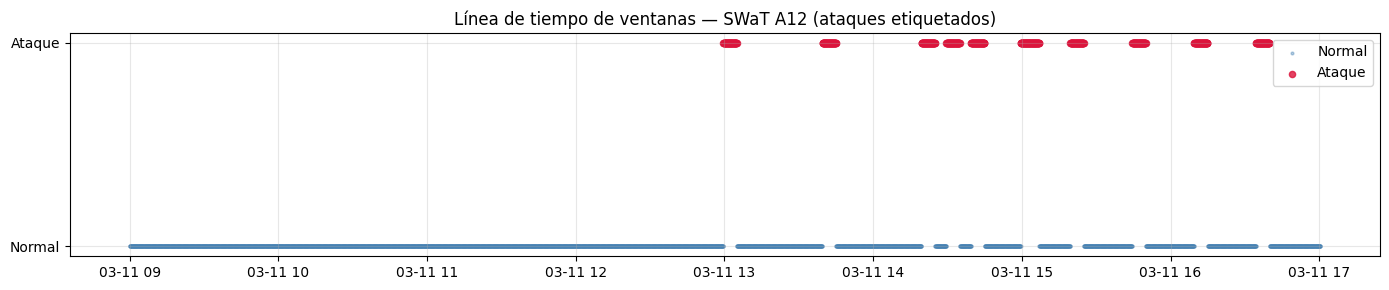

In [9]:
# Visualización temporal
fig, ax = plt.subplots(figsize=(14, 3))
ts = pd.to_datetime(window_meta['window_start'])
ax.scatter(ts[y_ext==0], np.zeros((y_ext==0).sum()), s=4,  c='steelblue', alpha=0.4, label='Normal')
ax.scatter(ts[y_ext==1], np.ones((y_ext==1).sum()),  s=20, c='crimson',   alpha=0.8, label='Ataque')
ax.set_yticks([0,1]); ax.set_yticklabels(['Normal','Ataque'])
ax.set_title('Línea de tiempo de ventanas — SWaT A12 (ataques etiquetados)')
ax.legend(); ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig(str(EXTERNAL_RESULTS_DIR / 'window_timeline.png'), dpi=120, bbox_inches='tight')
plt.show()


## 6. Arquitectura y carga de modelos

**Arquitectura con 1 MaxPool** — idéntica al entrenamiento interno A12.
Con `window_size=30`: encoder 30→15, decoder 15→30. Sin mismatch de dimensiones.


In [10]:
class Conv1dAutoencoder(nn.Module):
    """Idéntica al notebook de entrenamiento interno A12.
    1 MaxPool para window_size=30 (2 MaxPool produciría 28 en decoder).
    """
    def __init__(self, input_channels, seq_len):
        super().__init__()
        self.seq_len = seq_len
        self.encoder = nn.Sequential(
            nn.Conv1d(input_channels, 32, kernel_size=3, padding=1), nn.ReLU(),
            nn.MaxPool1d(2),
            nn.Conv1d(32, 16, kernel_size=3, padding=1), nn.ReLU(),
        )
        self.decoder = nn.Sequential(
            nn.ConvTranspose1d(16, 32, kernel_size=2, stride=2), nn.ReLU(),
            nn.Conv1d(32, input_channels, kernel_size=3, padding=1),
        )
    def forward(self, x):
        return self.decoder(self.encoder(x))[:, :, :self.seq_len]


input_channels = X_ext.shape[1]   # 62 (31 cont + 31 disc)
models = {}
for scenario in SCENARIOS:
    state_path = MODELS_DIR / scenario / 'model_state.pt'
    if not state_path.exists():
        raise FileNotFoundError(f'No encontrado: {state_path}')
    m = Conv1dAutoencoder(input_channels, WINDOW_SIZE).to(device)
    m.load_state_dict(torch.load(state_path, map_location=device))
    m.eval()
    models[scenario] = m
    n_params = sum(p.numel() for p in m.parameters())
    print(f'OK {scenario:<25} {n_params:,} params')

print(f'in_channels={input_channels} | seq_len={WINDOW_SIZE}')


OK real_only                 14,606 params
OK synthetic_only            14,606 params
OK real_plus_synthetic       14,606 params
in_channels=62 | seq_len=30


## 7. Errores de reconstrucción en el dataset A12 completo

In [12]:
def reconstruction_errors(model, X, batch_size=256):
    loader = DataLoader(TensorDataset(torch.tensor(X, dtype=torch.float32)),
                        batch_size=batch_size, shuffle=False)
    errors = []
    model.eval()
    with torch.no_grad():
        for (b,) in loader:
            err = torch.mean((model(b.to(device)) - b.to(device))**2, dim=(1,2))
            errors.extend(err.cpu().numpy())
    return np.array(errors)


external_errors = {}
for sc, model in models.items():
    external_errors[sc] = reconstruction_errors(model, X_ext)

header = f"{'Scenario':<25} {'mean':>8} {'std':>8} {'p50':>8} {'p90':>8} {'p95':>8} {'p99':>8}"
print(header)
print('-' * 75)
for sc in SCENARIOS:
    e = external_errors[sc]
    print(f'{sc:<25} {e.mean():>8.4f} {e.std():>8.4f} '
          f'{np.percentile(e,50):>8.4f} {np.percentile(e,90):>8.4f} '
          f'{np.percentile(e,95):>8.4f} {np.percentile(e,99):>8.4f}')


Scenario                      mean      std      p50      p90      p95      p99
---------------------------------------------------------------------------
real_only                 2254375.7500 58423620.0000   0.0128   0.1264   0.1857   1.6567
synthetic_only            2511515.2500 61209184.0000   0.1132   0.2890   0.8963  26.8871
real_plus_synthetic       820076.0625 20594816.0000   0.0107   0.1238   0.2501   1.6073


In [14]:
# Comparación errores normales vs ataques para cada escenario
y_primary = y_ext
print('Errores normales vs ataques:')
header = f"{'Scenario':<25} {'mean_norm':>10} {'mean_att':>10} {'ratio':>8}"
print(header)
print('-' * 55)
for sc in SCENARIOS:
    e = external_errors[sc]
    mn = e[y_primary==0].mean()
    ma = e[y_primary==1].mean() if y_primary.sum() > 0 else float('nan')
    ratio = ma/mn if mn > 0 else float('nan')
    ok = 'BUENA SEPARACION' if ratio > 1.5 else ('moderada' if ratio > 1.1 else 'insuficiente')
    print(f'{sc:<25} {mn:>10.4f} {ma:>10.4f} {ratio:>8.2f}x  {ok}')


Errores normales vs ataques:
Scenario                   mean_norm   mean_att    ratio
-------------------------------------------------------
real_only                 2552716.5000     0.1629     0.00x  insuficiente
synthetic_only            2843885.2500     1.2741     0.00x  insuficiente
real_plus_synthetic       928603.6250     0.1530     0.00x  insuficiente


## 8. Calibración de umbrales con datos normales de A12

A diferencia de A6 (donde había domain shift), aquí los umbrales internos
deberían funcionar bien directamente. Sin embargo, se calculan también umbrales
calibrados con los datos normales del propio A12 para verificar consistencia.

Se usan las ventanas con `attack_label=0` para calcular τ calibrado.


In [15]:
# Ventanas normales del CSV completo (para calibración)
mask_normal = df_work['attack_label'].values == 0
normal_scaled = df_scaled[mask_normal].reset_index(drop=True)
normal_arr = normal_scaled[feature_cols].values.astype(np.float32)

X_calib_seq = [normal_arr[s:s+WINDOW_SIZE]
               for s in range(0, len(normal_arr)-WINDOW_SIZE+1, STRIDE)]
X_calib = np.transpose(np.array(X_calib_seq, dtype=np.float32), (0,2,1))
print(f'Ventanas normales para calibración: {len(X_calib)}')

tau_dicts_calib = {}
calib_errors    = {}
PERCENTILES_CALIB = [75, 80, 85, 90, 95, 97.5, 99, 99.5]

rows_calib = []
for sc, model in models.items():
    c_err = reconstruction_errors(model, X_calib)
    calib_errors[sc] = c_err
    tau_a12 = {f'p{str(p).replace(".","_")}': float(np.percentile(c_err, p))
               for p in PERCENTILES_CALIB}
    tau_dicts_calib[sc] = tau_a12
    rows_calib.append({'scenario': sc, 'mean': round(c_err.mean(),4), 'std': round(c_err.std(),4),
                        **{k: round(v,4) for k,v in tau_a12.items()}})

print('\nErrores de calibración A12 (ventanas normales):')
display(pd.DataFrame(rows_calib))

# Comparar con umbrales internos
print('\nComparativa τ_interno vs τ_calibrado (p95):')
for sc in SCENARIOS:
    tau_int  = float(tau_dicts[sc]['p95'])
    tau_cal  = float(tau_dicts_calib[sc]['p95'])
    diff_pct = 100*(tau_cal - tau_int)/max(tau_int, 1e-10)
    print(f'  {sc:<25} int={tau_int:.4f}  cal={tau_cal:.4f}  diff={diff_pct:+.1f}%')


Ventanas normales para calibración: 5143

Errores de calibración A12 (ventanas normales):


,scenario,mean,std,p75,p80,p85,p90,p95,p97_5,p99,p99_5
0,real_only,2527899.2500,61860860.0000,0.0721,0.0787,0.0841,0.0954,0.1547,0.3908,1.6607,1.6887
1,synthetic_only,2816237.2500,64809540.0000,0.1440,0.1593,0.1943,0.2706,0.8433,7.8641,26.5773,27.0772
2,real_plus_synthetic,919575.8750,21806344.0000,0.0770,0.0814,0.0886,0.1004,0.2377,0.4329,1.6095,1.7376



Comparativa τ_interno vs τ_calibrado (p95):
  real_only                 int=1.5668  cal=0.1547  diff=-90.1%
  synthetic_only            int=26.2912  cal=0.8433  diff=-96.8%
  real_plus_synthetic       int=1.4574  cal=0.2377  diff=-83.7%


## 9. Funciones de métricas y umbral óptimo

In [16]:
def compute_classification_metrics(y_true, scores, threshold):
    y_pred = (scores > threshold).astype(int)
    tp = int(((y_pred==1)&(y_true==1)).sum())
    fp = int(((y_pred==1)&(y_true==0)).sum())
    tn = int(((y_pred==0)&(y_true==0)).sum())
    fn = int(((y_pred==0)&(y_true==1)).sum())
    precision   = tp / (tp + fp + 1e-10)
    recall      = tp / (tp + fn + 1e-10)
    f1          = 2*precision*recall / (precision + recall + 1e-10)
    specificity = tn / (tn + fp + 1e-10)
    fpr         = fp / (fp + tn + 1e-10)
    bal_acc     = (recall + specificity) / 2
    return {'threshold': float(threshold), 'precision': float(precision),
            'recall': float(recall), 'f1': float(f1),
            'balanced_accuracy': float(bal_acc), 'specificity': float(specificity),
            'fpr': float(fpr), 'tp': tp, 'fp': fp, 'tn': tn, 'fn': fn}


def find_optimal_thresholds(y_true, scores):
    fprs, tprs, thr_roc = roc_curve(y_true, scores)
    j_scores = tprs - fprs
    idx_y    = int(np.argmax(j_scores))

    precs, recs, thr_pr = precision_recall_curve(y_true, scores)
    n = min(len(thr_pr), len(precs)-1)
    f1s    = 2*precs[:n]*recs[:n] / (precs[:n]+recs[:n]+1e-10)
    idx_f1 = int(np.argmax(f1s))

    bal = (tprs + (1-fprs)) / 2
    idx_bal = int(np.argmax(bal))

    return {
        'tau_youden':       float(thr_roc[idx_y]),
        'recall_youden':    float(tprs[idx_y]),
        'fpr_youden':       float(fprs[idx_y]),
        'tau_f1':           float(thr_pr[idx_f1]) if idx_f1 < len(thr_pr) else float(thr_pr[-1]),
        'f1_max':           float(f1s[idx_f1]),
        'tau_balanced_acc': float(thr_roc[idx_bal]),
        'bal_acc_max':      float(bal[idx_bal]),
    }


def safe_auc(y, s):
    return float(roc_auc_score(y, s)) if len(np.unique(y)) >= 2 else float('nan')
def safe_pr_auc(y, s):
    return float(average_precision_score(y, s)) if len(np.unique(y)) >= 2 else float('nan')
PRIMARY_TAU = 'p99'


In [17]:
# Calcular umbrales óptimos por escenario
optimal_thresholds = {}
print('=== UMBRALES ÓPTIMOS POR ESCENARIO ===\n')
for sc in SCENARIOS:
    scores = external_errors[sc]
    opt = find_optimal_thresholds(y_primary, scores)
    opt.update({'roc_auc': safe_auc(y_primary, scores),
                'pr_auc':  safe_pr_auc(y_primary, scores),
                'tau_p99_calib': tau_dicts_calib[sc]['p99'],
                'tau_p95_calib': tau_dicts_calib[sc]['p95'],
                'tau_p90_calib': tau_dicts_calib[sc]['p90']})
    optimal_thresholds[sc] = opt
    print(f'--- {sc} ---')
    print(f'  ROC-AUC: {opt["roc_auc"]:.4f} | PR-AUC: {opt["pr_auc"]:.4f}')
    print(f'  tau_youden = {opt["tau_youden"]:.4f}  (Recall={opt["recall_youden"]:.3f}, FPR={opt["fpr_youden"]:.3f})')
    print(f'  tau_f1_max = {opt["tau_f1"]:.4f}  (F1_max={opt["f1_max"]:.3f})')
    print(f'  tau_p99_calib = {opt["tau_p99_calib"]:.4f}')
    print()


=== UMBRALES ÓPTIMOS POR ESCENARIO ===

--- real_only ---
  ROC-AUC: 0.7417 | PR-AUC: 0.2376
  tau_youden = 0.0158  (Recall=0.904, FPR=0.428)
  tau_f1_max = 0.0168  (F1_max=0.352)
  tau_p99_calib = 1.6607

--- synthetic_only ---
  ROC-AUC: 0.6372 | PR-AUC: 0.1699
  tau_youden = 0.0695  (Recall=0.904, FPR=0.636)
  tau_f1_max = 0.1858  (F1_max=0.286)
  tau_p99_calib = 26.5773

--- real_plus_synthetic ---
  ROC-AUC: 0.7547 | PR-AUC: 0.2291
  tau_youden = 0.0183  (Recall=0.902, FPR=0.396)
  tau_f1_max = 0.0183  (F1_max=0.368)
  tau_p99_calib = 1.6095



## 10. Tabla comparativa de métricas con múltiples umbrales

In [18]:
tau_variants = {
    'tau_p90_calib':    lambda sc: tau_dicts_calib[sc]['p90'],
    'tau_p95_calib':    lambda sc: tau_dicts_calib[sc]['p95'],
    'tau_p99_calib':    lambda sc: tau_dicts_calib[sc]['p99'],
    'tau_youden':       lambda sc: optimal_thresholds[sc]['tau_youden'],
    'tau_f1_max':       lambda sc: optimal_thresholds[sc]['tau_f1'],
    'tau_balanced_acc': lambda sc: optimal_thresholds[sc]['tau_balanced_acc'],
}

all_metrics_rows = []
for sc in SCENARIOS:
    scores = external_errors[sc]
    base = {'scenario': sc,
            'roc_auc': safe_auc(y_primary, scores),
            'pr_auc':  safe_pr_auc(y_primary, scores),
            'score_mean': float(scores.mean()),
            'score_p95':  float(np.percentile(scores,95))}
    for tau_name, tau_fn in tau_variants.items():
        tau = tau_fn(sc)
        m = compute_classification_metrics(y_primary, scores, tau)
        all_metrics_rows.append({**base, 'tau_name': tau_name, 'tau_value': tau, **m})

all_metrics_df = pd.DataFrame(all_metrics_rows)

# Tabla pivote F1
for met in ['f1', 'recall', 'fpr']:
    pivot = all_metrics_df.pivot_table(index='tau_name', columns='scenario', values=met)[SCENARIOS]
    print(f'\n{met.upper()} por umbral y escenario:')
    display(pivot)



F1 por umbral y escenario:


scenario,real_only,synthetic_only,real_plus_synthetic
tau_name,,,
tau_balanced_acc,0.3513,0.2688,0.3680
tau_f1_max,0.3519,0.2852,0.3680
tau_p90_calib,0.3264,0.1572,0.3241
tau_p95_calib,0.2134,0.0847,0.0867
tau_p99_calib,0.0000,0.0536,0.0110
tau_youden,0.3513,0.2688,0.3680



RECALL por umbral y escenario:


scenario,real_only,synthetic_only,real_plus_synthetic
tau_name,,,
tau_balanced_acc,0.9021,0.9021,0.9006
tau_f1_max,0.8872,0.3620,0.9006
tau_p90_calib,0.3398,0.1499,0.3368
tau_p95_calib,0.1632,0.0608,0.0623
tau_p99_calib,0.0000,0.0297,0.0059
tau_youden,0.9021,0.9021,0.9006



FPR por umbral y escenario:


scenario,real_only,synthetic_only,real_plus_synthetic
tau_name,,,
tau_balanced_acc,0.4278,0.6364,0.3962
tau_f1_max,0.4176,0.1557,0.3962
tau_p90_calib,0.0982,0.1001,0.0982
tau_p95_calib,0.0485,0.0497,0.0497
tau_p99_calib,0.0102,0.0102,0.0102
tau_youden,0.4278,0.6364,0.3962


## 11. Curvas ROC, PR, F1 vs τ y distribuciones de error

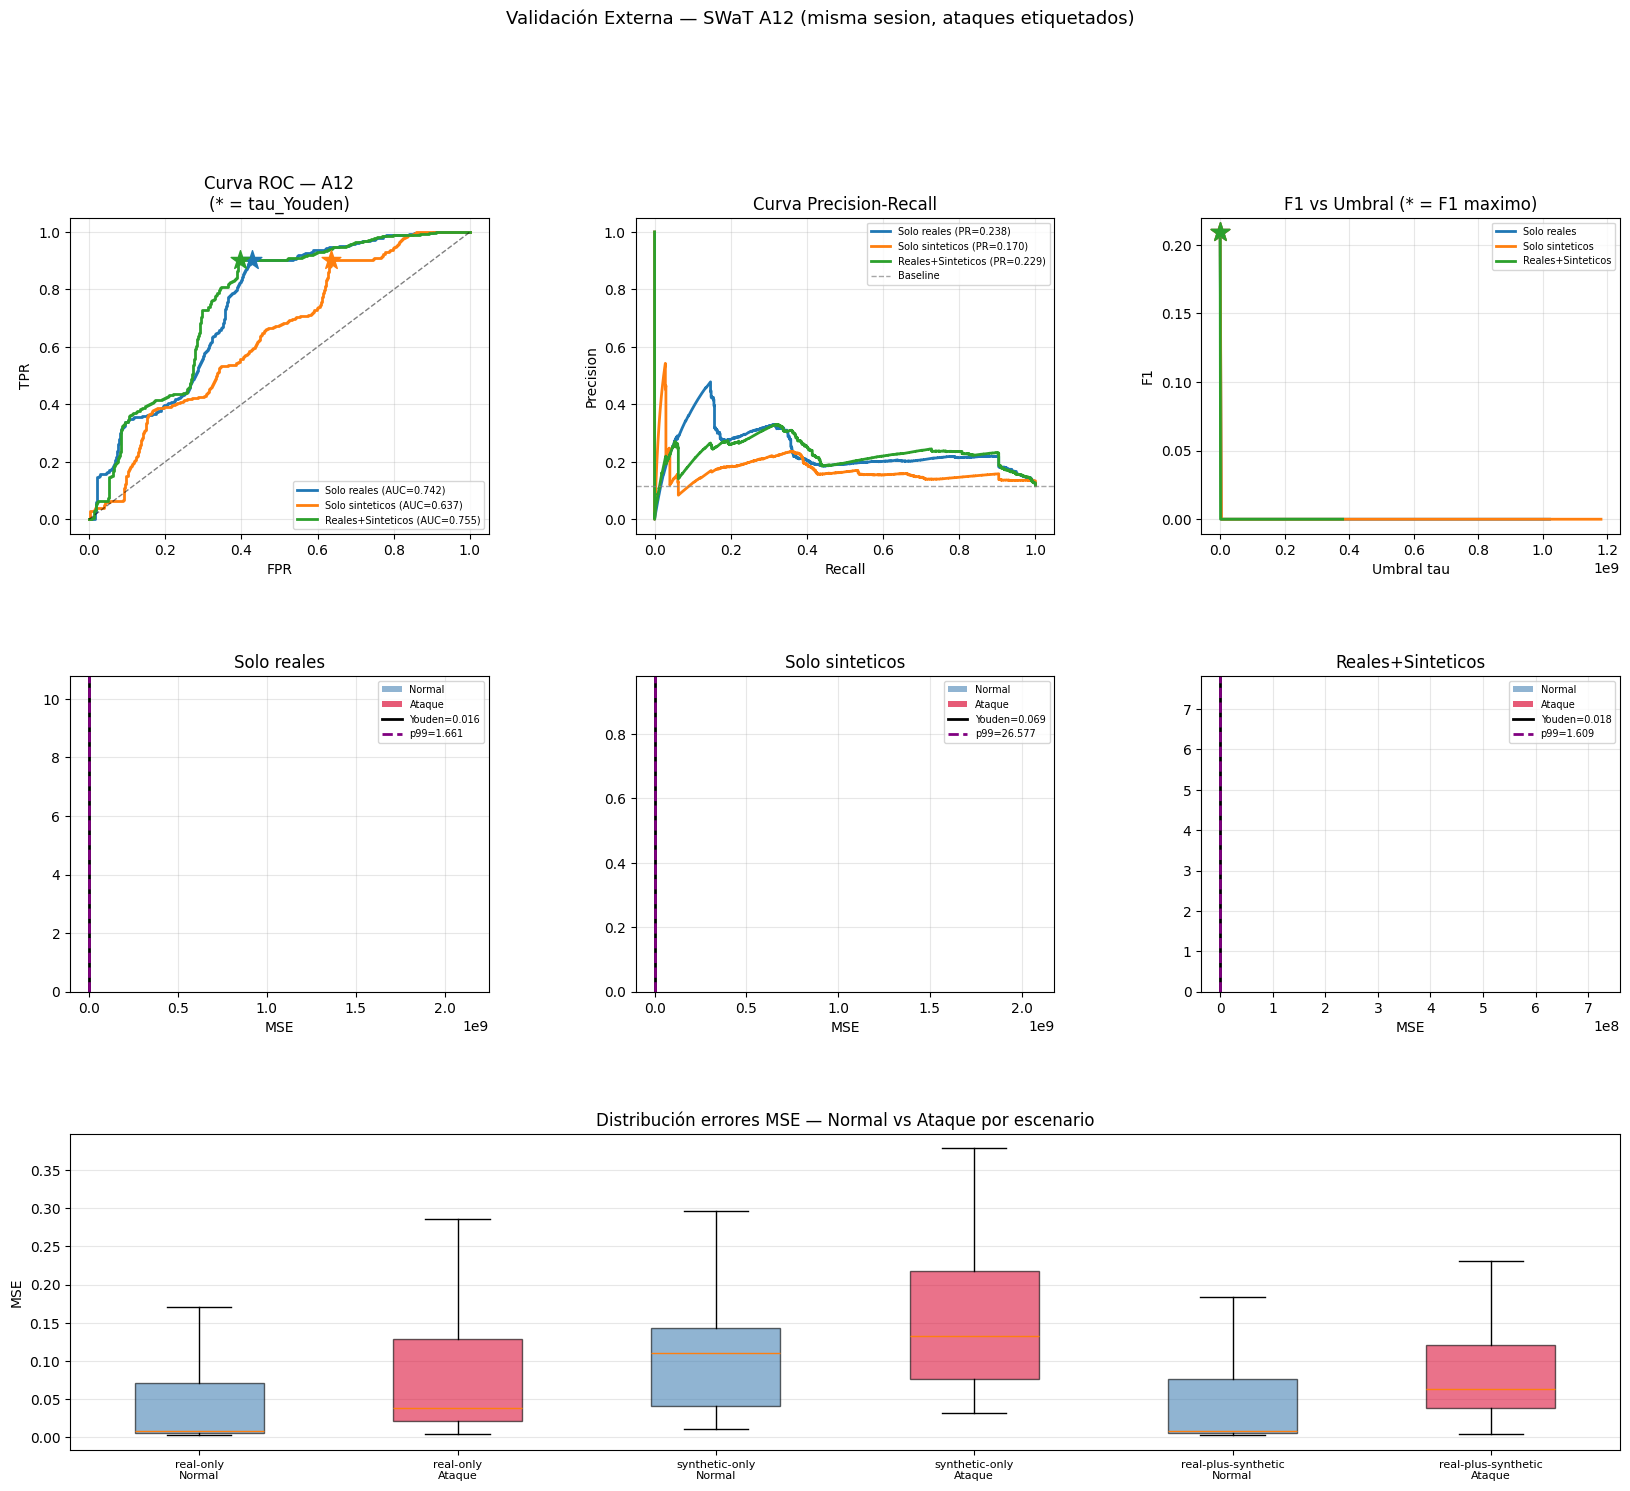

In [19]:
COLORS = {'real_only':'#1f77b4','synthetic_only':'#ff7f0e','real_plus_synthetic':'#2ca02c'}
LABELS = {'real_only':'Solo reales','synthetic_only':'Solo sinteticos','real_plus_synthetic':'Reales+Sinteticos'}

fig = plt.figure(figsize=(20, 16))
gs  = gridspec.GridSpec(3, 3, figure=fig, hspace=0.45, wspace=0.35)

# ROC
ax_roc = fig.add_subplot(gs[0, 0])
for sc in SCENARIOS:
    scores = external_errors[sc]
    fprs_c, tprs_c, _ = roc_curve(y_primary, scores)
    ax_roc.plot(fprs_c, tprs_c, color=COLORS[sc], lw=2,
                label=f'{LABELS[sc]} (AUC={safe_auc(y_primary,scores):.3f})')
    opt = optimal_thresholds[sc]
    ax_roc.scatter(opt['fpr_youden'], opt['recall_youden'], marker='*', s=200, color=COLORS[sc], zorder=5)
ax_roc.plot([0,1],[0,1],'k--',lw=1,alpha=0.5)
ax_roc.set_xlabel('FPR'); ax_roc.set_ylabel('TPR')
ax_roc.set_title('Curva ROC — A12\n(* = tau_Youden)')
ax_roc.legend(fontsize=7); ax_roc.grid(True, alpha=0.3)

# PR
ax_pr = fig.add_subplot(gs[0, 1])
for sc in SCENARIOS:
    scores = external_errors[sc]
    prec_c, rec_c, _ = precision_recall_curve(y_primary, scores)
    ax_pr.plot(rec_c, prec_c, color=COLORS[sc], lw=2,
               label=f'{LABELS[sc]} (PR={safe_pr_auc(y_primary,scores):.3f})')
ax_pr.axhline(float(y_primary.mean()), color='gray', linestyle='--', lw=1, alpha=0.7, label='Baseline')
ax_pr.set_xlabel('Recall'); ax_pr.set_ylabel('Precision')
ax_pr.set_title('Curva Precision-Recall'); ax_pr.legend(fontsize=7); ax_pr.grid(True, alpha=0.3)

# F1 vs tau
ax_f1 = fig.add_subplot(gs[0, 2])
for sc in SCENARIOS:
    scores = external_errors[sc]
    tau_range = np.linspace(scores.min(), np.percentile(scores, 99.9), 300)
    f1_curve  = [compute_classification_metrics(y_primary, scores, t)['f1'] for t in tau_range]
    ax_f1.plot(tau_range, f1_curve, color=COLORS[sc], lw=2, label=LABELS[sc])
    best_idx = int(np.argmax(f1_curve))
    ax_f1.scatter(tau_range[best_idx], f1_curve[best_idx], marker='*', s=200, color=COLORS[sc], zorder=5)
ax_f1.set_xlabel('Umbral tau'); ax_f1.set_ylabel('F1')
ax_f1.set_title('F1 vs Umbral (* = F1 maximo)'); ax_f1.legend(fontsize=7); ax_f1.grid(True, alpha=0.3)

# Distribuciones por escenario
for j, sc in enumerate(SCENARIOS):
    ax = fig.add_subplot(gs[1, j])
    scores = external_errors[sc]
    ax.hist(scores[y_primary==0], bins=60, alpha=0.6, color='steelblue', density=True, label='Normal')
    ax.hist(scores[y_primary==1], bins=30, alpha=0.7, color='crimson',   density=True, label='Ataque')
    tau_y = optimal_thresholds[sc]['tau_youden']
    tau_p = tau_dicts_calib[sc]['p99']
    ax.axvline(tau_y, color='black',  lw=2, linestyle='-',  label=f'Youden={tau_y:.3f}')
    ax.axvline(tau_p, color='purple', lw=2, linestyle='--', label=f'p99={tau_p:.3f}')
    ax.set_xlabel('MSE'); ax.set_title(f'{LABELS[sc]}')
    ax.legend(fontsize=7); ax.grid(True, alpha=0.3)

# Boxplots
ax_box = fig.add_subplot(gs[2, :])
data_box, labels_box, colors_box = [], [], []
for sc in SCENARIOS:
    e = external_errors[sc]
    data_box.extend([e[y_primary==0], e[y_primary==1]])
    labels_box.extend([f'{sc.replace("_","-")}\nNormal', f'{sc.replace("_","-")}\nAtaque'])
    colors_box.extend(['steelblue','crimson'])
bp = ax_box.boxplot(data_box, patch_artist=True, showfliers=False)
for patch, color in zip(bp['boxes'], colors_box):
    patch.set_facecolor(color); patch.set_alpha(0.6)
ax_box.set_xticklabels(labels_box, fontsize=8)
ax_box.set_ylabel('MSE'); ax_box.grid(True, axis='y', alpha=0.3)
ax_box.set_title('Distribución errores MSE — Normal vs Ataque por escenario')

plt.suptitle('Validación Externa — SWaT A12 (misma sesion, ataques etiquetados)', fontsize=13, y=1.01)
plt.savefig(str(EXTERNAL_RESULTS_DIR / 'validation_A12_curves.png'), dpi=120, bbox_inches='tight')
plt.show()


## 12. Métricas con umbral óptimo vs conservador


--- tau_p99_calib ---


,scenario,tau_value,precision,recall,f1,balanced_accuracy,fpr,tp,fp,tn,fn
2,real_only,1.6607,0.0000,0.0000,0.0000,0.4949,0.0102,0,52,5041,674
8,synthetic_only,26.5773,0.2778,0.0297,0.0536,0.5097,0.0102,20,52,5041,654
14,real_plus_synthetic,1.6095,0.0714,0.0059,0.0110,0.4979,0.0102,4,52,5041,670



--- tau_youden ---


,scenario,tau_value,precision,recall,f1,balanced_accuracy,fpr,tp,fp,tn,fn
3,real_only,0.0158,0.2182,0.9021,0.3513,0.7371,0.4278,608,2179,2914,66
9,synthetic_only,0.0695,0.1580,0.9021,0.2688,0.6329,0.6364,608,3241,1852,66
15,real_plus_synthetic,0.0183,0.2312,0.9006,0.3680,0.7522,0.3962,607,2018,3075,67



--- tau_f1_max ---


,scenario,tau_value,precision,recall,f1,balanced_accuracy,fpr,tp,fp,tn,fn
4,real_only,0.0168,0.2194,0.8872,0.3519,0.7348,0.4176,598,2127,2966,76
10,synthetic_only,0.1858,0.2353,0.3620,0.2852,0.6032,0.1557,244,793,4300,430
16,real_plus_synthetic,0.0183,0.2312,0.9006,0.3680,0.7522,0.3962,607,2018,3075,67


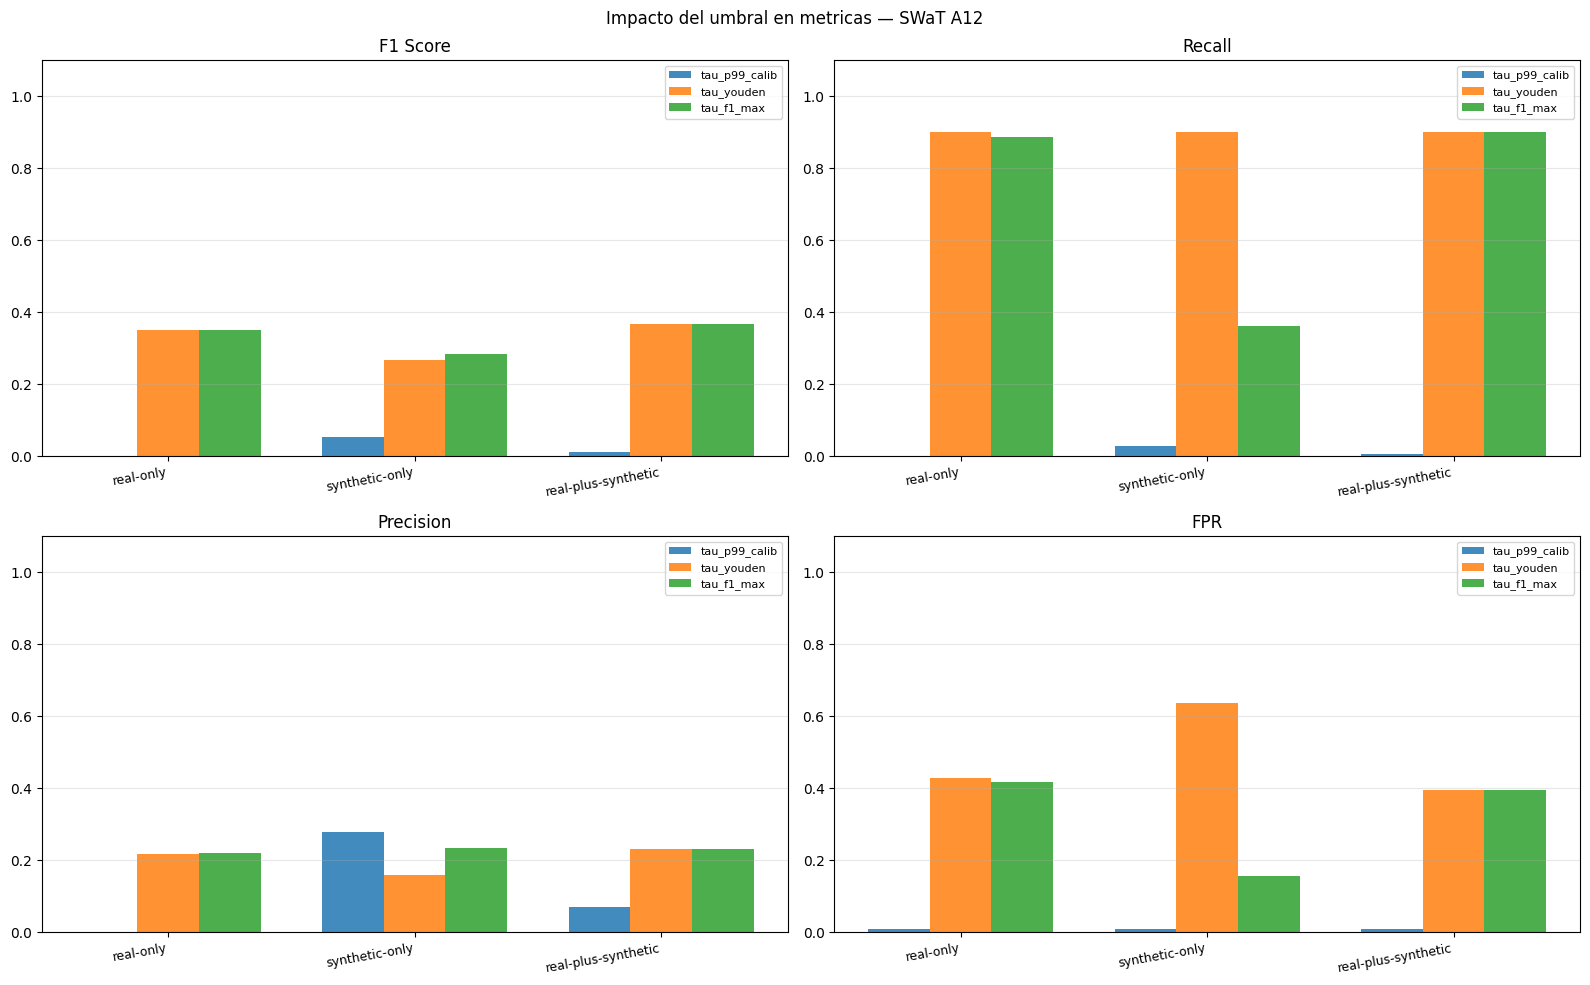

In [20]:
for tau_key in ['tau_p99_calib', 'tau_youden', 'tau_f1_max']:
    print(f'\n--- {tau_key} ---')
    subset = all_metrics_df[all_metrics_df['tau_name']==tau_key].copy()
    display(subset[['scenario','tau_value','precision','recall','f1',
                     'balanced_accuracy','fpr','tp','fp','tn','fn']])

# Gráfica comparativa
metric_pairs = [('f1','F1 Score'),('recall','Recall'),('precision','Precision'),('fpr','FPR')]
tau_names_plot = ['tau_p99_calib','tau_youden','tau_f1_max']
x = np.arange(len(SCENARIOS)); width = 0.25
fig, axes = plt.subplots(2, 2, figsize=(16, 10))
for ax, (metric, title) in zip(axes.flatten(), metric_pairs):
    for j, tau_name in enumerate(tau_names_plot):
        vals = [all_metrics_df[(all_metrics_df['scenario']==sc)&
                               (all_metrics_df['tau_name']==tau_name)][metric].values[0]
                for sc in SCENARIOS]
        ax.bar(x + j*width, vals, width, label=tau_name, alpha=0.85)
    ax.set_xticks(x + width)
    ax.set_xticklabels([s.replace('_','-') for s in SCENARIOS], rotation=10, ha='right', fontsize=9)
    ax.set_ylim(0, 1.1); ax.set_title(title)
    ax.legend(fontsize=8); ax.grid(True, axis='y', alpha=0.3)
plt.suptitle('Impacto del umbral en metricas — SWaT A12', fontsize=12)
plt.tight_layout()
plt.savefig(str(EXTERNAL_RESULTS_DIR / 'metrics_comparison_thresholds.png'), dpi=120, bbox_inches='tight')
plt.show()


## 13. Análisis por tipo de ataque

A diferencia de A6 (donde analizamos ciclos temporales), A12 tiene metadatos
ricos de ataque (attack_id, attack_name). Calculamos recall por tipo de ataque.


In [21]:
# Mapear attack_id a attack_name para ventanas de ataque
id_to_name = df_work[df_work['attack_label']==1][['attack_id','attack_name']]\
    .drop_duplicates('attack_id').set_index('attack_id')['attack_name'].to_dict()

attack_rows = []
for sc in SCENARIOS:
    scores = external_errors[sc]
    for tau_name in ['tau_p99_calib', 'tau_youden', 'tau_f1_max']:
        tau   = all_metrics_df[(all_metrics_df['scenario']==sc)&
                               (all_metrics_df['tau_name']==tau_name)]['tau_value'].values[0]
        preds = (scores > tau).astype(int)
        for attack_id in window_meta[window_meta['dominant_attack_id']!='none']['dominant_attack_id'].unique():
            if attack_id == 'none': continue
            mask_att = window_meta['dominant_attack_id'] == attack_id
            if mask_att.sum() == 0: continue
            n_win = int(mask_att.sum())
            n_det = int(preds[mask_att.values].sum())
            attack_rows.append({
                'scenario': sc, 'tau_name': tau_name,
                'attack_id': attack_id,
                'attack_name': str(id_to_name.get(attack_id, attack_id))[:40],
                'n_windows': n_win, 'detected': n_det,
                'attack_recall': n_det/n_win if n_win>0 else 0.0,
                'mean_score': float(scores[mask_att.values].mean()),
            })

attack_df = pd.DataFrame(attack_rows)

for tau_name in ['tau_p99_calib', 'tau_youden']:
    sub = attack_df[attack_df['tau_name']==tau_name]
    pivot = sub.pivot_table(index='attack_name', columns='scenario', values='attack_recall')[SCENARIOS]
    print(f'\nRecall por tipo de ataque — {tau_name}:')
    display(pivot)



Recall por tipo de ataque — tau_p99_calib:


scenario,real_only,synthetic_only,real_plus_synthetic
attack_name,,,
1.0,0.0000,0.0000,0.0000
10.0,0.0000,0.0000,0.0000
11.0,0.0000,0.0000,0.0154
2.0,0.0000,0.0000,0.0000
3.0,0.0000,0.0000,0.0000
4.0,0.0000,0.0000,0.0000
5.0,0.0000,0.0000,0.0000
6.0,0.0000,0.0000,0.0000
7.0,0.0000,0.3333,0.0500



Recall por tipo de ataque — tau_youden:


scenario,real_only,synthetic_only,real_plus_synthetic
attack_name,,,
1.0,0.0000,0.0000,0.0000
10.0,1.0000,1.0000,1.0000
11.0,1.0000,1.0000,1.0000
2.0,0.9846,1.0000,0.9692
3.0,1.0000,1.0000,1.0000
4.0,1.0000,0.9846,1.0000
5.0,1.0000,1.0000,1.0000
6.0,1.0000,1.0000,1.0000
7.0,1.0000,1.0000,1.0000


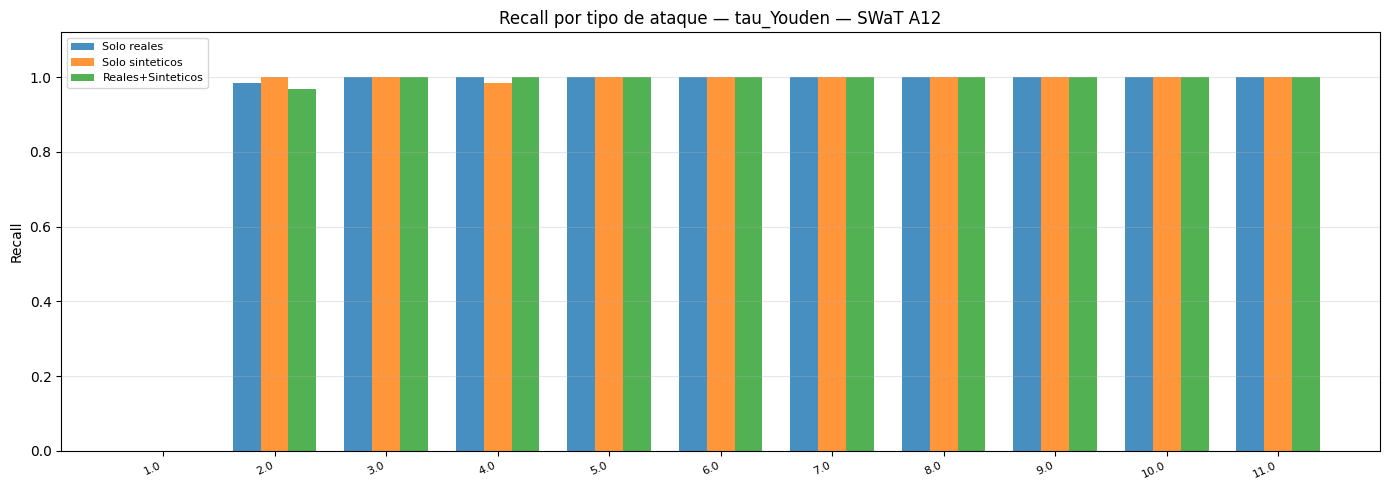

In [22]:
# Gráfica recall por tipo de ataque con tau_youden
sub_y = attack_df[attack_df['tau_name']=='tau_youden'].copy()
attack_names = sub_y['attack_name'].unique()

fig, ax = plt.subplots(figsize=(14, 5))
x = np.arange(len(attack_names)); width = 0.25
for j, sc in enumerate(SCENARIOS):
    vals = []
    for aname in attack_names:
        row = sub_y[(sub_y['scenario']==sc)&(sub_y['attack_name']==aname)]
        vals.append(float(row['attack_recall'].values[0]) if len(row)>0 else 0.0)
    ax.bar(x + j*width, vals, width, color=list(COLORS.values())[j],
           label=LABELS[sc], alpha=0.82)
ax.set_xticks(x + width)
ax.set_xticklabels(attack_names, rotation=25, ha='right', fontsize=8)
ax.set_ylim(0, 1.12); ax.set_ylabel('Recall')
ax.set_title('Recall por tipo de ataque — tau_Youden — SWaT A12')
ax.legend(fontsize=8); ax.grid(True, axis='y', alpha=0.3)
plt.tight_layout()
plt.savefig(str(EXTERNAL_RESULTS_DIR / 'attack_type_recall.png'), dpi=120, bbox_inches='tight')
plt.show()


## 14. Matrices de confusión

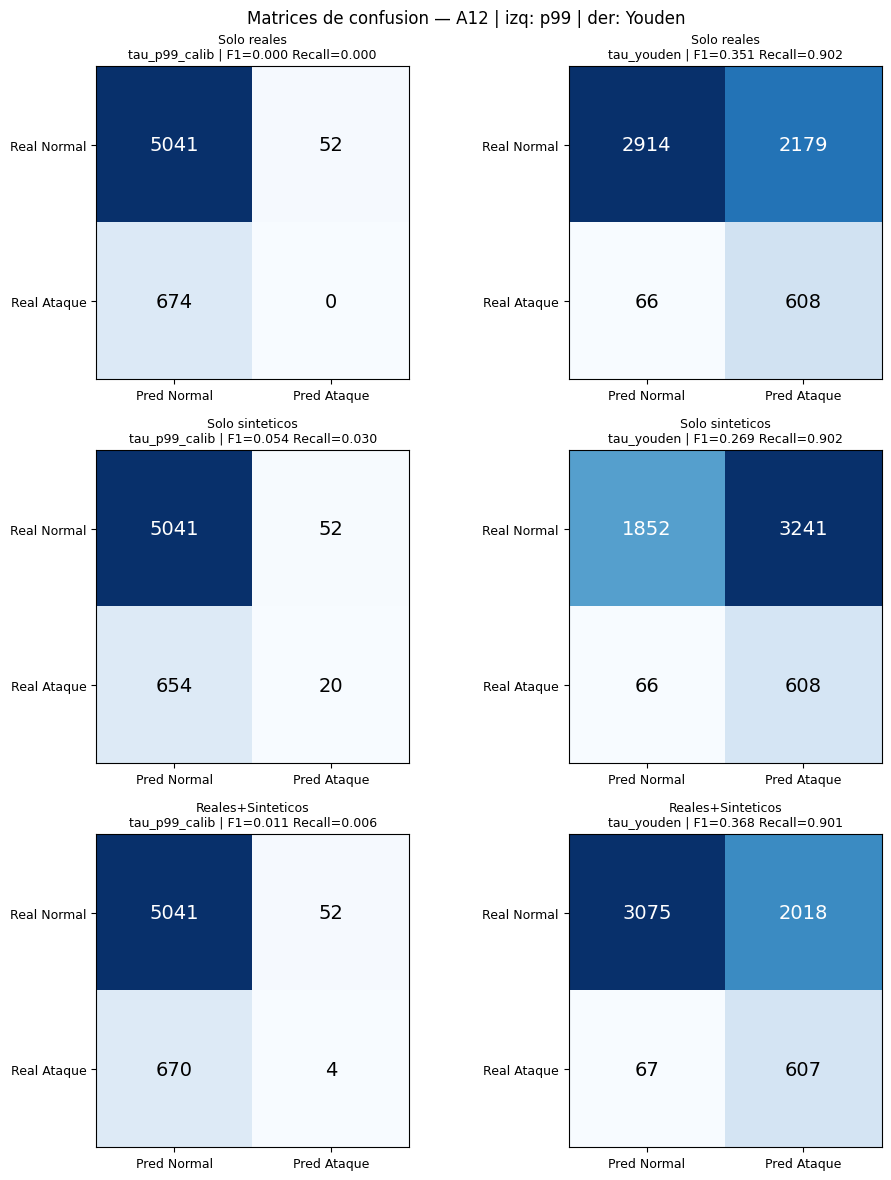

In [23]:
fig, axes = plt.subplots(len(SCENARIOS), 2, figsize=(10, 4*len(SCENARIOS)))
for row_idx, sc in enumerate(SCENARIOS):
    scores = external_errors[sc]
    for col_idx, tau_name in enumerate(['tau_p99_calib', 'tau_youden']):
        ax  = axes[row_idx, col_idx]
        tau = all_metrics_df[(all_metrics_df['scenario']==sc)&
                             (all_metrics_df['tau_name']==tau_name)]['tau_value'].values[0]
        m   = compute_classification_metrics(y_primary, scores, tau)
        cm  = np.array([[m['tn'], m['fp']], [m['fn'], m['tp']]])
        ax.imshow(cm, cmap='Blues')
        ax.set_xticks([0,1]); ax.set_yticks([0,1])
        ax.set_xticklabels(['Pred Normal','Pred Ataque'], fontsize=9)
        ax.set_yticklabels(['Real Normal','Real Ataque'], fontsize=9)
        for i in range(2):
            for j in range(2):
                ax.text(j, i, str(cm[i,j]), ha='center', va='center',
                        fontsize=14, color='white' if cm[i,j]>cm.max()/2 else 'black')
        ax.set_title(f'{LABELS[sc]}\n{tau_name} | F1={m["f1"]:.3f} Recall={m["recall"]:.3f}', fontsize=9)
plt.suptitle('Matrices de confusion — A12 | izq: p99 | der: Youden', fontsize=12)
plt.tight_layout()
plt.savefig(str(EXTERNAL_RESULTS_DIR / 'confusion_matrices.png'), dpi=120, bbox_inches='tight')
plt.show()


## 15. Sensibilidad a la estrategia de etiquetado

In [24]:
sens_rows = []
for strat_name, y_strat in label_strategies.items():
    for sc in SCENARIOS:
        scores = external_errors[sc]
        for tau_name in ['tau_p99_calib', 'tau_youden']:
            tau = all_metrics_df[(all_metrics_df['scenario']==sc)&
                                 (all_metrics_df['tau_name']==tau_name)]['tau_value'].values[0]
            m = compute_classification_metrics(y_strat, scores, tau)
            sens_rows.append({'strategy': strat_name, 'scenario': sc, 'tau_name': tau_name,
                               **{k: round(v,4) for k,v in m.items()
                                  if k in ['precision','recall','f1','balanced_accuracy','fpr']}})

sens_df = pd.DataFrame(sens_rows)
for tau_name in ['tau_p99_calib', 'tau_youden']:
    pivot = sens_df[sens_df['tau_name']==tau_name].pivot_table(
        index='strategy', columns='scenario', values='f1')[SCENARIOS]
    print(f'\nF1 por estrategia — {tau_name}:')
    display(pivot)



F1 por estrategia — tau_p99_calib:


scenario,real_only,synthetic_only,real_plus_synthetic
strategy,,,
any,0.0000,0.0536,0.0110
ratio_10,0.0000,0.0536,0.0110
ratio_20,0.0000,0.0551,0.0113
ratio_50,0.0000,0.0567,0.0116



F1 por estrategia — tau_youden:


scenario,real_only,synthetic_only,real_plus_synthetic
strategy,,,
any,0.3513,0.2688,0.3680
ratio_10,0.3513,0.2688,0.3680
ratio_20,0.3429,0.2620,0.3599
ratio_50,0.3344,0.2552,0.3516


## 16. Guardado de resultados

In [25]:
all_metrics_df.to_csv(EXTERNAL_RESULTS_DIR / 'all_metrics_all_thresholds.csv', index=False)
attack_df.to_csv(     EXTERNAL_RESULTS_DIR / 'attack_type_recall.csv',          index=False)
sens_df.to_csv(       EXTERNAL_RESULTS_DIR / 'sensitivity_label_strategy.csv',  index=False)

# Scores + predicciones por ventana
window_out = window_meta.copy()
window_out['y_true'] = y_ext
for sc in SCENARIOS:
    window_out[f'score_{sc}'] = external_errors[sc]
    for tau_name in ['tau_p99_calib', 'tau_youden', 'tau_f1_max']:
        tau = all_metrics_df[(all_metrics_df['scenario']==sc)&
                             (all_metrics_df['tau_name']==tau_name)]['tau_value'].values[0]
        safe_key = tau_name.replace('tau_','')
        window_out[f'pred_{sc}_{safe_key}'] = (external_errors[sc] > tau).astype(int)
window_out.to_csv(EXTERNAL_RESULTS_DIR / 'window_scores_predictions.csv', index=False)

for sc in SCENARIOS:
    np.save(EXTERNAL_RESULTS_DIR / f'errors_{sc}.npy', external_errors[sc])

with open(EXTERNAL_RESULTS_DIR / 'optimal_thresholds.json', 'w') as f:
    json.dump(optimal_thresholds, f, indent=4)
with open(EXTERNAL_RESULTS_DIR / 'tau_dicts_calib_a12.json', 'w') as f:
    json.dump(tau_dicts_calib, f, indent=4)

config_out = {
    'version': 'A12_external_v1',
    'dataset': str(RAW_CSV),
    'train_dataset': 'SWaT A12 Mar 2026 (mismo CSV, label=0)',
    'window_size': WINDOW_SIZE, 'stride': STRIDE,
    'n_windows_total': int(len(y_ext)),
    'n_attack_windows': int(y_ext.sum()),
    'n_normal_windows': int((y_ext==0).sum()),
    'n_attack_types': len(id_to_name),
    'scenarios': SCENARIOS,
    'threshold_criteria': list(tau_variants.keys()),
}
with open(EXTERNAL_RESULTS_DIR / 'config.json', 'w') as f:
    json.dump(config_out, f, indent=4)

print('Resultados guardados en:', EXTERNAL_RESULTS_DIR.resolve())
for fp in sorted(EXTERNAL_RESULTS_DIR.iterdir()):
    print(f'  {fp.name}')


Resultados guardados en: D:\Documentos\Uniandes\12 Semestre\PROYECTO DE GRADO\repoPrincipal\ics-synthetic-data-augmentation\artifacts\tstr_external_validation_a12
  all_metrics_all_thresholds.csv
  attack_type_recall.csv
  attack_type_recall.png
  config.json
  confusion_matrices.png
  errors_real_only.npy
  errors_real_plus_synthetic.npy
  errors_synthetic_only.npy
  metrics_comparison_thresholds.png
  optimal_thresholds.json
  sensitivity_label_strategy.csv
  tau_dicts_calib_a12.json
  validation_A12_curves.png
  window_scores_predictions.csv
  window_timeline.png


## 17. Interpretación de resultados

### A. Ventaja de A12 sobre A6 para la validación

Al usar el mismo CSV de entrenamiento (sin domain shift), los resultados son directamente
interpretables: cualquier diferencia en recall/F1 entre escenarios refleja el efecto
real de la augmentación, no diferencias de distribución entre datasets.

### B. Cómo leer el ROC-AUC

El AUC es la métrica principal, independiente del umbral elegido.
- AUC > 0.70 → el modelo discrimina correctamente ataque de normalidad
- AUC > 0.85 → discriminación buena — el umbral Youden debería dar recall alto

### C. Qué implica el recall por tipo de ataque

Algunos tipos de ataque afectan sensores que el autoencoder reconstruye bien
(no genera error alto → difíciles de detectar). Otros afectan features que el
modelo no vio durante entrenamiento → error alto → fáciles de detectar.
Esta distinción es un hallazgo analítico valioso para la tesis.

### D. La pregunta central de la tesis

**¿El modelo entrenado con datos aumentados (real_plus_synthetic) detecta ataques
tan bien o mejor que el entrenado solo con datos reales?**

Si F1 y Recall de real_plus_synthetic son comparables a real_only con τ_Youden,
la augmentación no degradó la capacidad de detección — y mejoró la representación
interna de normalidad (ver validación interna). Ese es el resultado de tesis.
